# Task 1: Download and Visualize Sentinel 2 Data

In this task we focus on the municipality of **São Félix do Xingu** in the eastern sector of Pará state in Brazil. The goal is to retrieve two Sentinel 2 tiles from the Copernicus AWS archive for two dates, to then analyse the forest loss.

## 1.0 Optional Step: Global Forest Watch Data Review

Before working with spectral data we can consult Global Forest Watch for annual forest cover change statistics in São Félix do Xingu.
Please look at the [Global Forest Watch map for São Félix do Xingu, Brazil](https://gfw.global/43UgsJg) and evaluate the forst loss in the region.


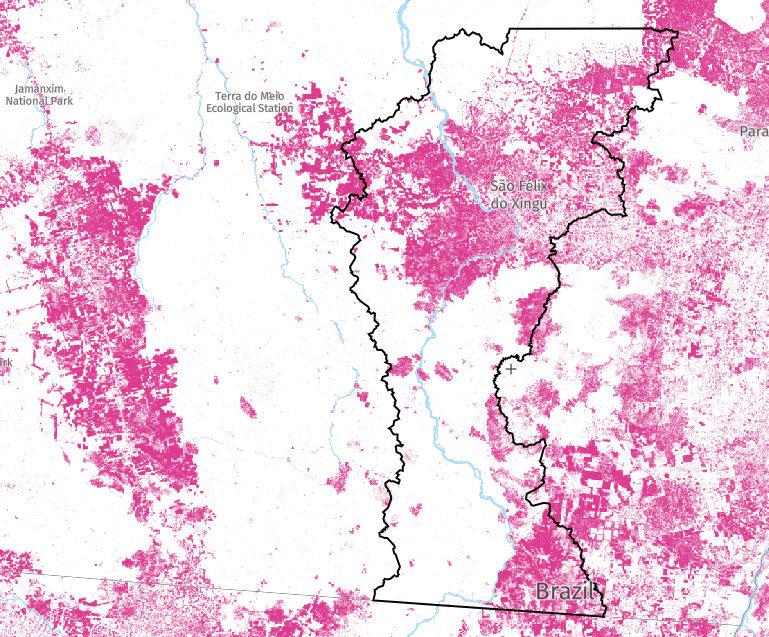


According to Global Forest Watch, São Félix do Xingu experienced a loss of 2.1 million hectares of tree cover between 2001 and 2024, which is about a 27 percent decrease. In the more recent period from 2018 to 2024 the municipality lost 790 thousand hectares of tree cover equivalent to a 10 percent decrease in tree cover and to 350 million tonnes of carbon dioxide equivalent emissions. 
To align our satellite imagery analysis with both the magnitude of recent forest loss and the availability of high quality Sentinel 2 acquisitions we focus on the years 2018 and 2024. 

###  Contextual and Seasonal Considerations

To interpret these forest-cover statistics we must consider the principal land-use drivers in São Félix do Xingu; cattle ranching expansion and commercial agriculture have accelerated canopy removal in recent years, and infrastructure development such as logging roads can fragment contiguous forest blocks. We also note that the municipality contains both humid tropical forest and transitional savanna-forest mosaic.

Furthermore we must account for seasonal and atmospheric factors when selecting our two dates; the dry season in this region, roughly July through September, offers the clearest skies for optical imagery whereas the wet season introduces increased cloud cover and potential sun-glint off wet leaves. 




## 1.1 Accessing Earth Observation Data via Copernicus Data Space S3

To download Sentinel-2 products from Copernicus Data Space via S3 you must first register for the Data Space service by creating a Copernicus user account. Once authenticated you can generate S3 credentials comprising an access key ID and a secret access key (see [Copernicus Data Space S3 API documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html)). Store these credentials securely in a `.env` file at the project root so that they can be loaded at runtime without exposing sensitive information.

### Detailed Task description
1. Register and obtain S3 credentials from Copernicus Data Space, store your access key ID and secret access key in a `.env` file.
   (Please do not upload this file for the submission)

   The .env file should look like this:

   ```
   AWS_ACCESS_KEY_ID=[YOURACCESSKEYHERE]
   AWS_SECRET_ACCESS_KEY=[YOURSECRETHERE]
   ```

### Imports

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)

In [2]:
from datetime import date
import time
from pathlib import Path
from typing import Optional, Iterable, Tuple

import boto3
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from dotenv import load_dotenv
from collections import defaultdict
import geopandas as gpd
from shapely.geometry import Polygon

import matplotlib.pyplot as plt
import rasterio

pd.set_option('display.max_columns', None)  
pd.set_option('display.max_colwidth', None) 

DESIRED_BANDS = [
    "B02_10m",
    "B03_10m",
    "B04_10m",
    "B05_20m",
    "B06_20m",
    "B07_20m",
    "B08_10m",
    "B8A_20m",
    "B11_20m",
    "B12_20m",
]

dotenv_candidates = [
    Path.cwd() / ".env",
    Path.cwd() / "src/ipl4eo_miniproject_2026/.env",
    *[directory / ".env" for directory in Path.cwd().parents],
]
dotenv_path = next((path for path in dotenv_candidates if path.exists()), None)

if dotenv_path is not None:
    load_dotenv(dotenv_path=dotenv_path)

access_key = os.getenv("AWS_ACCESS_KEY_ID")
secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
cdse_username = os.getenv("CDSE_USERNAME")
cdse_password = os.getenv("CDSE_PASSWORD")

## 1.2 Querying the Copernicus OData API for Sentinel-2 Data

In this step, you will identify and retrieve Sentinel-2 Level 2A (L2A) imagery for São Félix do Xingu for two specific dry season periods. The goal is to obtain comparable data from both 2018 and 2024 for subsequent analysis.

**Note:** Sentinel-2 L2A products are atmospherically corrected surface reflectance data, processed from Level 1C using the Sen2Cor processor. For detailed information on these products, refer to the [Sentinel-2 L2A documentation](https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a).

### Detailed Task description

1. Query the Copernicus OData API to retrieve Sentinel-2 Level 2A products satisfying the following constraints for both 2018 and 2024:

- **Area of interest:** Full envelope of São Félix do Xingu
- **Acquisition dates:** Between 20 July and 30 July  
- **Cloud cover:** Maximum of 0.5%  
- **Product type:** Level 2A (atmospherically corrected products)  
- **Spatial consistency:** Retain only those Sentinel-2 tiles that are present in both years (based on tile name)
- **Most recent tiles per year:** e.g. if a tile with Tile-ID T22MCU exists multiple times per year keep only one with the latest acquisition date 

   You can use the function `dataspace_dataframe_from_attributes` to obtain the dataframe (see Lab01). Retrieve only the metadata for now, you do not need to download the tiles.

2. Convert both resulting DataFrames into GeoDataFrames using the available spatial metadata. Visualize them with the `explore()` method to verify whether the selected tiles overlap spatially. The tiles should be visualized in yellow for 2018, red for 2024 and green where there is an overlap. Helpful pointers are [gdf explore](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.explore.html), [gpd overlay](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html#geopandas.GeoDataFrame.overlay).
3. Print: Number of tiles in 2018 (total area in 2018), Number of tiles in 2024 (total area in 2024), intersection area (overlap area), percent of coverage of intersection over 2018 area, percent of coverage of intersection over 2024 area, intersection over union between 2018 and 2024 (intersection_2018_2024 / union_2018_2024). All areas should be in square kilometers and intersections in percent. Output should look exactly like:
   
   ```
    Tiles 2018: ..., Area: ... km²
    Tiles 2024: ..., Area: ... km²
    Overlap Area: ... km²
    Overlap = ...% of 2018
    Overlap = ...% of 2024
    Intersection over Union (IoU) = ...%
   ```

   Hint: The coordinate reference system is relevant for calculating areas. You can get the unit of measurement of the current system via
   ```python
   gdf.crs.axis_info[0].unit_name
   ```

   If it is in degrees you need to reproject to a common crs with units in meters.
   
4. Describe your findings briefly.


##### `dataspace_dataframe_from_attributes()`

In [3]:
def dataspace_dataframe_from_attributes(
    collection: str = "SENTINEL-2",
    aoi: Optional[str] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    attributes: Optional[Iterable[Tuple[str, str, float]]] = None,
    string_attributes: Optional[Iterable[Tuple[str, str]]] = None,
    max_returned_items: int = 20
):
    """
    Get a dataframe of items from the Copernicus DataSpace API based on the given attributes.
    The request is build based on the OData standard as documented at
    https://documentation.dataspace.copernicus.eu/APIs/OData.html

    Parameters
    ----------
    collection : str
        The collection to search for. Default is "SENTINEL-2".
    aoi : str, optional
        The area of interest in WKT format. Default is None.
    start_date : str, optional
        The start date in the format "YYYY-MM-DD". Default is None.
    end_date : str, optional
        The end date in the format "YYYY-MM-DD". Default is None.
    attributes : Iterable[Tuple[str, str, float]], optional
        The attributes to filter by. Default is None which means no filtering and is equivalent to an empty list.
        Each tuple should be in the format (key, comparison, value).
        The comparison should be one of "lt", "le", "eq", "ge", "gt".
        Currently only attributes of type double and that are comparable are supported.
    string_attributes : Iterable[Tuple[str, str]], optional
        String attributes in the format (key, value).
    max_returned_items : int, optional
        The maximum number of items to return. Default is 20. Must be in [0, 1000].
    """
    if attributes is None:
        attributes = []

    if string_attributes is None:
        string_attributes = []
        
    request_str = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter="
    request_str += f"Collection/Name eq '{collection}'"
    if aoi is not None:
        request_str += f" and OData.CSC.Intersects(area=geography'SRID=4326;{aoi}')"
    if start_date is not None:
        request_str += f" and ContentDate/Start ge {start_date}T00:00:00.000Z"
    if end_date is not None:
        request_str += f" and ContentDate/Start lt {end_date}T00:00:00.000Z"
    for k, comp, v in attributes:
        assert comp in ["lt", "le", "eq", "ge", "gt"]
        request_str += f" and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq '{k}' and att/OData.CSC.DoubleAttribute/Value {comp} {v:.2f})"
    for k, v in string_attributes:
        request_str += f" and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq '{k}' and att/OData.CSC.StringAttribute/Value eq '{v}')" 
    # get all attributes
    request_str += "&$expand=Attributes"
    # get top n items
    assert 0 <= max_returned_items <= 1000, f"Copernicus API only allows returned items in [0, 1000], but {max_returned_items} is outside this range."
    request_str += f"&$top={max_returned_items}"
    json_result = requests.get(request_str).json()
    json_vals = json_result['value']
    return pd.DataFrame.from_dict(json_result['value'])

##### `copernicus_df_to_gdf()`

In [4]:
def copernicus_df_to_gdf(copernicus_df: pd.DataFrame, strftime: Optional[str] = None) -> gpd.GeoDataFrame:
    if strftime is not None and strftime.lower() in ['iso', 'iso 8601', 'default']:
        strftime = '%Y-%m-%dT%H:%M:%S'
    df = copernicus_df.copy()
    # split footprint into geometry (wkt text) and crs
    # assign crs
    crss = df['Footprint'].apply(lambda x: "EPSG:"+x.split(';')[0].split("'")[1].split('=')[1])
    assert len(crss.unique()) == 1, "Multiple CRS values in data frame, geopandas can't handle that."
    # assign geometry
    df['geometry'] = gpd.GeoSeries.from_wkt(df['Footprint'].apply(lambda x: x.split(';')[1].split("'")[0]), crs=crss.iloc[0])
    gdf = gpd.GeoDataFrame(df)
    attribute_names = set(sl['Name'] for l in gdf['Attributes'] for sl in l)
    ignored_date_conversions = []
    successful_date_conversions = []
    for attr in attribute_names:
        gdf[attr] = gdf['Attributes'].apply(lambda x: [i for i in x if i['Name'] == attr][0]['Value'] if len([i for i in x if i['Name'] == attr]) > 0 else np.NaN)
    for attr in gdf.columns:
        if 'Date' in attr:
            # convert to DateTime
            try:
                gdf[attr] = pd.to_datetime(gdf[attr], yearfirst=True, format='mixed')
                # convert to numeric or string to make it json-serializable
                if strftime is None:
                    gdf[attr] = gdf[attr].values.astype(np.int64) // 10 ** 9
                else:
                    gdf[attr] = gdf[attr].dt.strftime(strftime)
            except Exception as e:
                ignored_date_conversions += [attr]
                continue
            successful_date_conversions += [attr]
    print(f"Ignored date conversions: {ignored_date_conversions}")
    print(f"Successful date conversions: {successful_date_conversions}")
    return gdf

##### `keep_latest_acquisition_per_tile()`

In [5]:
def keep_latest_acquisition_per_tile(
    gdf: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:
    result = gdf.copy()

    def get_content_start(value):
        if isinstance(value, dict):
            return value["Start"]
        return value

    result["acquisition_datetime"] = pd.to_datetime(
        result["ContentDate"].apply(get_content_start),
        utc=True,
        errors="raise",
    )

    result = (
        result
        .sort_values(
            ["tileId", "acquisition_datetime"],
            kind="stable",
        )
        .drop_duplicates(
            subset="tileId",
            keep="last",
        )
        .reset_index(drop=True)
    )

    return result

##### Prepare data

In [6]:
municipality = ox.geocode_to_gdf("São Félix do Xingu, Pará, Brazil").to_crs("EPSG:4326")
aoi_geometry = municipality.geometry.union_all().envelope
aoi_wkt=aoi_geometry.wkt

raw_df_2018 = dataspace_dataframe_from_attributes(
    collection="SENTINEL-2",
    aoi=aoi_wkt,
    start_date="2018-07-20",
    end_date="2018-07-31",
    attributes=[("cloudCover", "le", 0.5)],
    string_attributes=[("productType", "S2MSI2A")],
    max_returned_items=1000,
)
raw_gdf_2018 = copernicus_df_to_gdf(raw_df_2018, strftime="ISO")

raw_df_2024 = dataspace_dataframe_from_attributes(
    collection="SENTINEL-2",
    aoi=aoi_wkt,
    start_date="2024-07-20",
    end_date="2024-07-31",
    attributes=[("cloudCover", "le", 0.5)],
    string_attributes=[("productType", "S2MSI2A")],
    max_returned_items=1000,
)
raw_gdf_2024 = copernicus_df_to_gdf(raw_df_2024, strftime="ISO")

gdf_2018 = keep_latest_acquisition_per_tile(raw_gdf_2018)
gdf_2024 = keep_latest_acquisition_per_tile(raw_gdf_2024)

Ignored date conversions: ['EvictionDate', 'ContentDate']
Successful date conversions: ['OriginDate', 'PublicationDate', 'ModificationDate', 'processingDate', 'beginningDateTime', 'endingDateTime']
Ignored date conversions: ['EvictionDate', 'ContentDate', 'sourceProductOriginDate']
Successful date conversions: ['OriginDate', 'PublicationDate', 'ModificationDate', 'processingDate', 'beginningDateTime', 'endingDateTime']


##### Get common tile IDs

In [7]:
common_tile_ids = (
    set(gdf_2018["tileId"]) &
    set(gdf_2024["tileId"])
)

gdf_2018 = (
    gdf_2018[
        gdf_2018["tileId"].isin(common_tile_ids)
    ]
    .copy()
    .sort_values("tileId")
    .reset_index(drop=True)
)

gdf_2024 = (
    gdf_2024[
        gdf_2024["tileId"].isin(common_tile_ids)
    ]
    .copy()
    .sort_values("tileId")
    .reset_index(drop=True)
)

assert set(gdf_2018["tileId"]) == set(gdf_2024["tileId"])
assert gdf_2018["tileId"].is_unique
assert gdf_2024["tileId"].is_unique

##### Inspect data

In [8]:
gdf_2018.columns

Index(['@odata.mediaContentType', 'Id', 'Name', 'ContentType', 'ContentLength',
       'OriginDate', 'PublicationDate', 'ModificationDate', 'Online',
       'EvictionDate', 'S3Path', 'Checksum', 'ContentDate', 'Footprint',
       'GeoFootprint', 'Attributes', 'geometry', 'processingLevel',
       'platformShortName', 'productGroupId', 'cloudCover', 'processingDate',
       'instrumentShortName', 'orbitNumber', 'datastripId', 'productType',
       'tileId', 'platformSerialIdentifier', 'origin', 'beginningDateTime',
       'endingDateTime', 'processorVersion', 'relativeOrbitNumber',
       'acquisition_datetime'],
      dtype='object')

In [9]:
gdf_2018.head(1)

,@odata.mediaContentType,Id,Name,ContentType,ContentLength,OriginDate,PublicationDate,ModificationDate,Online,EvictionDate,S3Path,Checksum,ContentDate,Footprint,GeoFootprint,Attributes,geometry,processingLevel,platformShortName,productGroupId,cloudCover,processingDate,instrumentShortName,orbitNumber,datastripId,productType,tileId,platformSerialIdentifier,origin,beginningDateTime,endingDateTime,processorVersion,relativeOrbitNumber,acquisition_datetime
0,application/octet-stream,e4d6b44a-6119-48c3-a139-a5e42058d134,S2A_MSIL2A_20180728T135111_N0500_R024_T21LZK_20230722T202651.SAFE,application/octet-stream,973405761,2024-02-23T20:38:07,2024-02-23T20:49:07,2025-07-01T02:00:32,True,9999-12-31T23:59:59.999999Z,/eodata/Sentinel-2/MSI/L2A_N0500/2018/07/28/S2A_MSIL2A_20180728T135111_N0500_R024_T21LZK_20230722T202651.SAFE,"[{'Value': '691723ba4ea7fe61af8c0acdf9395049', 'Algorithm': 'MD5', 'ChecksumDate': '2025-07-01T02:00:30.402378Z'}, {'Value': '647ce16127db6b21b62bc7dd696b50d6ee77cae0010734f5166be36a82c3df77', 'Algorithm': 'BLAKE3', 'ChecksumDate': '2025-07-01T02:00:32.284468Z'}]","{'Start': '2018-07-28T13:51:11.024000Z', 'End': '2018-07-28T13:51:11.024000Z'}","geography'SRID=4326;POLYGON ((-54.185516 -10.0272712586801, -53.263275 -10.018274267923, -53.274048 -9.02727104254599, -53.958527 -9.03329418593914, -53.97589 -9.10959655429599, -54.009766 -9.25800967619987, -54.043518 -9.40650312585881, -54.077393 -9.55503646911728, -54.111176 -9.70356598587746, -54.145172 -9.85198505893114, -54.17929 -10.0002678973127, -54.185516 -10.0272712586801))'","{'type': 'Polygon', 'coordinates': [[[-54.185516, -10.0272712586801], [-53.263275, -10.018274267923], [-53.274048, -9.02727104254599], [-53.958527, -9.03329418593914], [-53.97589, -9.10959655429599], [-54.009766, -9.25800967619987], [-54.043518, -9.40650312585881], [-54.077393, -9.55503646911728], [-54.111176, -9.70356598587746], [-54.145172, -9.85198505893114], [-54.17929, -10.0002678973127], [-54.185516, -10.0272712586801]]]}","[{'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'origin', 'Value': 'ESA', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'tileId', 'Value': '21LZK', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.DoubleAttribute', 'Name': 'cloudCover', 'Value': 0.220772, 'ValueType': 'Double'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'datastripId', 'Value': 'S2A_OPER_MSI_L2A_DS_S2RP_20230722T202651_S20180728T135113_N05.00', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.IntegerAttribute', 'Name': 'orbitNumber', 'Value': 16180, 'ValueType': 'Integer'}, {'@odata.type': '#OData.CSC.DateTimeOffsetAttribute', 'Name': 'processingDate', 'Value': '2023-07-22T20:26:51.000000Z', 'ValueType': 'DateTimeOffset'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'productGroupId', 'Value': 'GS2A_20180728T135111_016180_N05.00', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'processingLevel', 'Value': 'S2MSI2A', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'processorVersion', 'Value': '05.00', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'platformShortName', 'Value': 'SENTINEL-2', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'instrumentShortName', 'Value': 'MSI', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.IntegerAttribute', 'Name': 'relativeOrbitNumber', 'Value': 24, 'ValueType': 'Integer'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'platformSerialIdentifier', 'Value': 'A', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'productType', 'Value': 'S2MSI2A', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.DateTimeOffsetAttribute', 'Name': 'beginningDateTime', 'Value': '2018-07-28T13:51:11.024000Z', 'ValueType': 'DateTimeOffset'}, {'@odata.type': '#OData.CSC.DateTimeOffsetAttribute', 'Name': 'endingDateTime', 'Value': '2018-07-28T13:51:11.024000Z', 'ValueType

In [10]:
gdf_2024.head(1)

,@odata.mediaContentType,Id,Name,ContentType,ContentLength,OriginDate,PublicationDate,ModificationDate,Online,EvictionDate,S3Path,Checksum,ContentDate,Footprint,GeoFootprint,Attributes,geometry,productGroupId,granuleIdentifier,sourceProductOriginDate,processingDate,datastripId,productType,processorVersion,sourceProduct,orbitNumber,tileId,origin,beginningDateTime,endingDateTime,processingLevel,platformShortName,operationalMode,cloudCover,instrumentShortName,platformSerialIdentifier,relativeOrbitNumber,acquisition_datetime
0,application/octet-stream,a122d9e5-4188-4304-a8e7-fc5bd55a984d,S2B_MSIL2A_20240721T134709_N0510_R024_T21LZK_20240721T160820.SAFE,application/octet-stream,983342579,2024-07-21T17:12:14,2024-07-21T17:20:22,2026-05-25T15:51:36,True,9999-12-31T23:59:59.999999Z,/eodata/Sentinel-2/MSI/L2A/2024/07/21/S2B_MSIL2A_20240721T134709_N0510_R024_T21LZK_20240721T160820.SAFE,"[{'Value': '359e2988f63481447cda5f1ef4a76c98', 'Algorithm': 'MD5', 'ChecksumDate': '2026-05-25T15:51:33.904586Z'}, {'Value': 'd4096e499600b2138e584301b264ba4ce016139aa0dd7bd108667fc69782d213', 'Algorithm': 'BLAKE3', 'ChecksumDate': '2026-05-25T15:51:36.007586Z'}]","{'Start': '2024-07-21T13:47:09.024000Z', 'End': '2024-07-21T13:47:09.024000Z'}","geography'SRID=4326;POLYGON ((-54.191274015519994 -10.027327519375147, -53.2632768589676 -10.018274267922964, -53.27404851720899 -9.02727104254599, -53.96346775614779 -9.033337603249162, -53.96984437404507 -9.061452662372137, -54.00376365282616 -9.209873380349304, -54.03764711656064 -9.358308006684885, -54.071621479478544 -9.506679748193106, -54.10559913536368 -9.654977063194236, -54.13963550866202 -9.80324338077946, -54.17385139611116 -9.951434283431226, -54.191274015519994 -10.027327519375147))'","{'type': 'Polygon', 'coordinates': [[[-54.191274015519994, -10.027327519375147], [-53.2632768589676, -10.018274267922964], [-53.27404851720899, -9.02727104254599], [-53.96346775614779, -9.033337603249162], [-53.96984437404507, -9.061452662372137], [-54.00376365282616, -9.209873380349304], [-54.03764711656064, -9.358308006684885], [-54.071621479478544, -9.506679748193106], [-54.10559913536368, -9.654977063194236], [-54.13963550866202, -9.80324338077946], [-54.17385139611116, -9.951434283431226], [-54.191274015519994, -10.027327519375147]]]}","[{'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'origin', 'Value': 'ESA', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'tileId', 'Value': '21LZK', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.DoubleAttribute', 'Name': 'cloudCover', 'Value': 0.001038, 'ValueType': 'Double'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'datastripId', 'Value': 'S2B_OPER_MSI_L2A_DS_2BPS_20240721T160820_S20240721T134707_N05.10', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.IntegerAttribute', 'Name': 'orbitNumber', 'Value': 38517, 'ValueType': 'Integer'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'sourceProduct', 'Value': 'S2B_OPER_MSI_L2A_TL_2BPS_20240721T160820_A038517_T21LZK_N05.10,S2B_OPER_MSI_L2A_DS_2BPS_20240721T160820_S20240721T134707_N05.10', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.DateTimeOffsetAttribute', 'Name': 'processingDate', 'Value': '2024-07-21T16:08:20.000000Z', 'ValueType': 'DateTimeOffset'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'productGroupId', 'Value': 'GS2B_20240721T134709_038517_N05.10', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'operationalMode', 'Value': 'INS-NOBS', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'processingLevel', 'Value': 'S2MSI2A', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'processorVersion', 'Value': '05.10', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name': 'granuleIdentifier', 'Value': 'S2B_OPER_MSI_L2A_TL_2BPS_20240721T160820_A038517_T21LZK_N05.10', 'ValueType': 'String'}, {'@odata.type': '#OData.CSC.StringAttribute', 'Name'

##### Calculate area

In [11]:
AREA_CRS = "EPSG:6933"

gdf_2018_projected = gdf_2018.to_crs(AREA_CRS)
gdf_2024_projected = gdf_2024.to_crs(AREA_CRS)

print("Projected unit:", gdf_2018_projected.crs.axis_info[0].unit_name)

coverage_2018 = gdf_2018_projected.geometry.union_all()
coverage_2024 = gdf_2024_projected.geometry.union_all()

intersection_2018_2024 = coverage_2018.intersection(coverage_2024)
union_2018_2024 = coverage_2018.union(coverage_2024)

Projected unit: metre


In [12]:
SQUARE_METERS_PER_SQUARE_KM = 1_000_000

area_2018_km2 = (coverage_2018.area / SQUARE_METERS_PER_SQUARE_KM)
area_2024_km2 = (coverage_2024.area / SQUARE_METERS_PER_SQUARE_KM)

intersection_area_km2 = (intersection_2018_2024.area / SQUARE_METERS_PER_SQUARE_KM)
union_area_km2 = (union_2018_2024.area / SQUARE_METERS_PER_SQUARE_KM)

if area_2018_km2 == 0:
    raise ValueError("The 2018 coverage area is zero.")

if area_2024_km2 == 0:
    raise ValueError("The 2024 coverage area is zero.")

if union_area_km2 == 0:
    raise ValueError("The union area is zero.")

overlap_percent_2018 = (intersection_area_km2 / area_2018_km2 * 100)
overlap_percent_2024 = (intersection_area_km2 / area_2024_km2 * 100)

iou_percent = (intersection_area_km2 / union_area_km2 * 100)

##### Stats

In [13]:
print(f"Number of common tiles: {len(common_tile_ids)}")
print("Common tile IDs:")
print(", ".join(sorted(common_tile_ids)))

Number of common tiles: 25
Common tile IDs:
21LZK, 21LZL, 21MZM, 21MZN, 22LBQ, 22LBR, 22LCQ, 22LCR, 22LDQ, 22LDR, 22LEQ, 22LER, 22MBS, 22MBT, 22MBU, 22MBV, 22MCS, 22MCT, 22MCU, 22MCV, 22MDS, 22MDT, 22MES, 22MET, 22MEU


In [14]:
number_of_tiles_2018 = len(gdf_2018)
number_of_tiles_2024 = len(gdf_2024)

print(
    f"Tiles 2018: {number_of_tiles_2018}, "
    f"Area: {area_2018_km2:.2f} km²"
)

print(
    f"Tiles 2024: {number_of_tiles_2024}, "
    f"Area: {area_2024_km2:.2f} km²"
)

print(f"Overlap Area: {intersection_area_km2:.2f} km²")
print(f"Overlap = {overlap_percent_2018:.2f}% of 2018")
print(f"Overlap = {overlap_percent_2024:.2f}% of 2024")

print(f"Intersection over Union (IoU) = {iou_percent:.2f}%")

Tiles 2018: 25, Area: 181090.61 km²
Tiles 2024: 25, Area: 195949.06 km²
Overlap Area: 137444.00 km²
Overlap = 75.90% of 2018
Overlap = 70.14% of 2024
Intersection over Union (IoU) = 57.36%


##### Visualization

In [15]:
coverage_2018_gdf = gpd.GeoDataFrame(
    {"year": ["2018"]},
    geometry=[coverage_2018],
    crs=AREA_CRS,
)

coverage_2024_gdf = gpd.GeoDataFrame(
    {"year": ["2024"]},
    geometry=[coverage_2024],
    crs=AREA_CRS,
)

only_2018_gdf = gpd.overlay(
    coverage_2018_gdf,
    coverage_2024_gdf,
    how="difference",
)

only_2024_gdf = gpd.overlay(
    coverage_2024_gdf,
    coverage_2018_gdf,
    how="difference",
)

overlap_gdf = gpd.overlay(
    coverage_2018_gdf,
    coverage_2024_gdf,
    how="intersection",
)

only_2018_gdf["region"] = "2018 only"
only_2024_gdf["region"] = "2024 only"
overlap_gdf["region"] = "2018 and 2024 overlap"

only_2018_map = only_2018_gdf.to_crs("EPSG:4326")
only_2024_map = only_2024_gdf.to_crs("EPSG:4326")
overlap_map = overlap_gdf.to_crs("EPSG:4326")

In [16]:
coverage_map = only_2018_map.explore(
    color="yellow",
    tooltip=["region"],
    style_kwds={
        "fillOpacity": 0.7,
        "weight": 1,
    },
)

coverage_map = only_2024_map.explore(
    m=coverage_map,
    color="red",
    tooltip=["region"],
    style_kwds={
        "fillOpacity": 0.7,
        "weight": 1,
    },
)

coverage_map = overlap_map.explore(
    m=coverage_map,
    color="green",
    tooltip=["region"],
    style_kwds={
        "fillOpacity": 0.8,
        "weight": 1,
    },
)

coverage_map

##### Findings

After retaining only the tile IDs present in both years and selecting the latest acquisition for each tile, both datasets contained 25 tiles. However, the spatial footprints were not identical. The overlap area was 137,444.00 km², corresponding to 75.90% of the 2018 coverage and 70.14% of the 2024 coverage. The IoU was 57.36%, indicating moderate spatial agreement rather than complete consistency. The 2024 dataset also covered a larger total area than the 2018 dataset.

## 1.3 Downloading and Visualizing Sentinel-2 Tile T22MCU

Based on the results of the previous step, we now narrow our analysis to a single tile. According to Global Forest Watch and our tile inspection using the GeoDataFrame, tile **T22MCU** lies in the northern sector of São Félix do Xingu, an area that has experienced significant deforestation between 2018 and 2024. The tile shows complete data coverage and spatially aligns with settlement and agricultural zones, making it a suitable candidate for further analysis.

The goal in this step is to programmatically download selected bands from the Sentinel-2 Level 2A products for tile T22MCU for both 2018 and 2024 and to visualize the corresponding RGB composites. 

To minimize storage overhead, we restrict the download to bands that are required for classification tasks compatible with the [BigEarthNet v2](https://arxiv.org/abs/1902.06148) label set. We use the AWS S3 API (via `boto3`) for efficient access. Refer to the same [Copernicus Data Space S3 API documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html) for endpoint configuration and signing instructions.

### Detailed Task Description

1. **Tile Selection**  
   From the GeoDataFrame constructed in Task 2.2, filter the entries to retain only those with `tileName == 'T22MCU'`. Confirm that exactly one product is retained for each of the two target years (2018 and 2024).

2. **Band Selection and Download via `boto3`**  
   Use the AWS SDK for Python (`boto3`) to authenticate with the Copernicus Data Space S3 endpoint using credentials stored in the `.env` file.  
   For each of the two selected products:
   - Access the product path from the S3 URL in the dataframe.
   - Retrieve only the following bands, organizing them into subfolders, respectively:

     ```
     DESIRED_BANDS = [
         'B02_10m', 'B03_10m', 'B04_10m', 'B05_20m',
         'B06_20m', 'B07_20m', 'B08_10m', 'B8A_20m',
         'B11_20m', 'B12_20m'
     ]
     ```

   Hint: There is a known limitation with the maximum path length under Windows. If you are unable to download the tiles because of this, please enable long paths as detailed [here](https://learn.microsoft.com/en-us/windows/win32/fileio/maximum-file-path-limitation?tabs=registry).

3. **RGB Composite Visualization**  
   For each year:
   - Stack bands `B04_10m` (red), `B03_10m` (green), and `B02_10m` (blue) into a 3-channel array.
   - Plot the normalized image.

4. **Interpretation**  
   Briefly describe the visual differences between the two images. Comment on land cover, visible clearings, vegetation patterns, or any atmospheric artifacts such as haze or clouds.




##### Config

In [17]:
TARGET_TILE_ID = "22MCU"
YEARS = [2018, 2024]

S3_BUCKET_NAME = "eodata"

S3_ENDPOINT_URL = "https://eodata.dataspace.copernicus.eu"
CDSE_TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
S3_KEYS_MANAGER_URL = "https://s3-keys-manager.cloudferro.com/api/user/credentials"

DOWNLOAD_ROOT = data_path / "T22MCU"

RGB_BANDS = {
    "R": "B04_10m",
    "G": "B03_10m",
    "B": "B02_10m",
}
DISPLAY_DOWNSAMPLE_FACTOR = 4

##### Select one product for each year

In [18]:
gdfs_by_year = {
    2018: gdf_2018,
    2024: gdf_2024,
}

selected_products = {}
"""
selected_products = {
    2018: <gdf row for 2018>,
    2024: <gdf row for 2024>
}
"""

for year in YEARS:
    gdf = gdfs_by_year[year]
    selected = gdf[gdf["tileId"] == TARGET_TILE_ID]

    if len(selected) != 1:
        raise ValueError(
            f"Expected exactly one T{TARGET_TILE} product for {year}, "
            f"but found {len(selected)}."
        )

    selected_products[year] = selected.iloc[0] # get first row

summary_columns = [
    "Name",
    "tileId",
    "acquisition_datetime",
    "cloudCover",
    "S3Path",
]
selected_product_summary = pd.DataFrame(
    [
        {"year": year, **row[summary_columns].to_dict()}
        for year, row in selected_products.items()
    ]
)
display(selected_product_summary)

,year,Name,tileId,acquisition_datetime,cloudCover,S3Path
0,2018,S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE,22MCU,2018-07-23 13:51:09.024000+00:00,0.000766,/eodata/Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE
1,2024,S2B_MSIL2A_20240721T134709_N0510_R024_T22MCU_20240721T160820.SAFE,22MCU,2024-07-21 13:47:09.024000+00:00,0.004210,/eodata/Sentinel-2/MSI/L2A/2024/07/21/S2B_MSIL2A_20240721T134709_N0510_R024_T22MCU_20240721T160820.SAFE


##### Connect to the S3 endpoint

In [19]:
def get_cdse_access_token():
    response = requests.post(
        CDSE_TOKEN_URL,
        data={
            "client_id": "cdse-public",
            "grant_type": "password",
            "username": cdse_username,
            "password": cdse_password,
        },
    )
    response.raise_for_status()
    return response.json()["access_token"]

def create_temporary_s3_credentials():
    access_token = get_cdse_access_token()
    headers = {
        "Authorization": f"Bearer {access_token}",
        "Accept": "application/json",
    }

    response = requests.post(
        S3_KEYS_MANAGER_URL,
        headers=headers,
    )
    response.raise_for_status()

    return response.json(), headers # credentials, headers

def create_s3_resource():
    if access_key and secret_key:
        resource = boto3.resource(
            "s3",
            endpoint_url=S3_ENDPOINT_URL,
            aws_access_key_id=access_key,
            aws_secret_access_key=secret_key,
            region_name="default",
        )
        return resource, None, None

    if cdse_username and cdse_password:
        credentials, headers = create_temporary_s3_credentials()
        time.sleep(5)
        resource = boto3.resource(
            "s3",
            endpoint_url=S3_ENDPOINT_URL,
            aws_access_key_id=credentials["access_id"],
            aws_secret_access_key=credentials["secret"],
        )
        return resource, credentials, headers

    raise RuntimeError("Copernicus credentials are missing from .env")

def delete_temporary_s3_credentials(credentials, headers):
    response = requests.delete(
        f"{S3_KEYS_MANAGER_URL}/access_id/{credentials['access_id']}",
        headers=headers,
    )
    response.raise_for_status()

In [20]:
s3_resource, temp_creds, temp_headers = create_s3_resource()
s3_bucket = s3_resource.Bucket(S3_BUCKET_NAME)

##### Dowanload the bands

In [21]:
def get_product_prefix(product):
    return product["S3Path"].removeprefix("/eodata/").rstrip("/")

# return : {<band_name>: <s3_key>}
def find_band_keys(product):
    product_prefix = get_product_prefix(product)
    band_keys = {} # {<band_name>: <s3_key>}

    for s3_object in s3_bucket.objects.filter(Prefix=product_prefix):
        s3_key = s3_object.key
        filename = Path(s3_key).stem # e.g. "T22MCU_20180812T_B02_10m"

        for band_name in DESIRED_BANDS:
            if filename.endswith(band_name):
                band_keys[band_name] = s3_key
                break

    missing_bands = [
        band_name
        for band_name in DESIRED_BANDS
        if band_name not in band_keys
    ]

    if missing_bands:
        raise FileNotFoundError(f"Missing bands: {', '.join(missing_bands)}")

    return band_keys

def download_product_bands(year, product):
    band_keys = find_band_keys(product)
    year_directory = DOWNLOAD_ROOT / str(year)
    year_directory.mkdir(parents=True, exist_ok=True)

    local_paths = {}
    downloaded_count = 0

    for band_name in DESIRED_BANDS:
        local_path = year_directory / f"{band_name}.jp2"

        if not local_path.exists():
            s3_resource.meta.client.download_file(
                S3_BUCKET_NAME,
                band_keys[band_name],
                str(local_path),
            )
            downloaded_count += 1

        local_paths[band_name] = local_path

    return local_paths, downloaded_count

In [22]:
band_files_by_year = {} # {<year>: [<band_path>]}
downloaded_summary_rows = []

for year in YEARS:
    band_paths, downloaded_count = download_product_bands(year, selected_products[year])

    band_files_by_year[year] = band_paths
    downloaded_summary_rows.append(
        {
            "year": year,
            "just_downloaded_count": downloaded_count,
            "already_exist": len(DESIRED_BANDS) - downloaded_count,
            "local_directory": str(DOWNLOAD_ROOT / str(year)),
        }
    )

downloaded_summary = pd.DataFrame(downloaded_summary_rows)
display(downloaded_summary)

,year,just_downloaded_count,already_exist,local_directory
0,2018,0,10,/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018
1,2024,0,10,/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2024


In [23]:
if temp_creds is not None:
    delete_temporary_s3_credentials(
        temp_creds,
        temp_headers,
    )
    print("Temporary S3 credentials deleted.")

print("All requested bands are available locally.")

All requested bands are available locally.


##### Create and visualize RGB composites

In [24]:
# return 2D numpy array
def read_band_for_display(path):
    with rasterio.open(path) as dataset: # read a .jp2 file
        output_height = dataset.height // DISPLAY_DOWNSAMPLE_FACTOR
        output_width = dataset.width // DISPLAY_DOWNSAMPLE_FACTOR

        band = dataset.read(
            1, # read the first (the only one) band
            out_shape=(output_height, output_width),
        )

    return band.astype(np.float32)

# return 2D numpy array with entry value between 0 and 1
def normalize_band(band):
    low, high = np.percentile(band, [2, 98])
    normalized = (band-low) / (high-low)
    return np.clip(normalized, 0, 1) # range: [0, 1]

# return numpy array with shape (output_height, output_width, 3)
def create_rgb_composite(band_paths):
    red = normalize_band(
        read_band_for_display(band_paths[RGB_BANDS["R"]])
    )
    green = normalize_band(
        read_band_for_display(band_paths[RGB_BANDS["G"]])
    )
    blue = normalize_band(
        read_band_for_display(band_paths[RGB_BANDS["B"]])
    )

    if not (red.shape == green.shape == blue.shape):
        raise ValueError(
            f"RGB bands have different shapes: "
            f"red={red.shape}, green={green.shape}, blue={blue.shape}"
        )

    return np.dstack([red, green, blue])

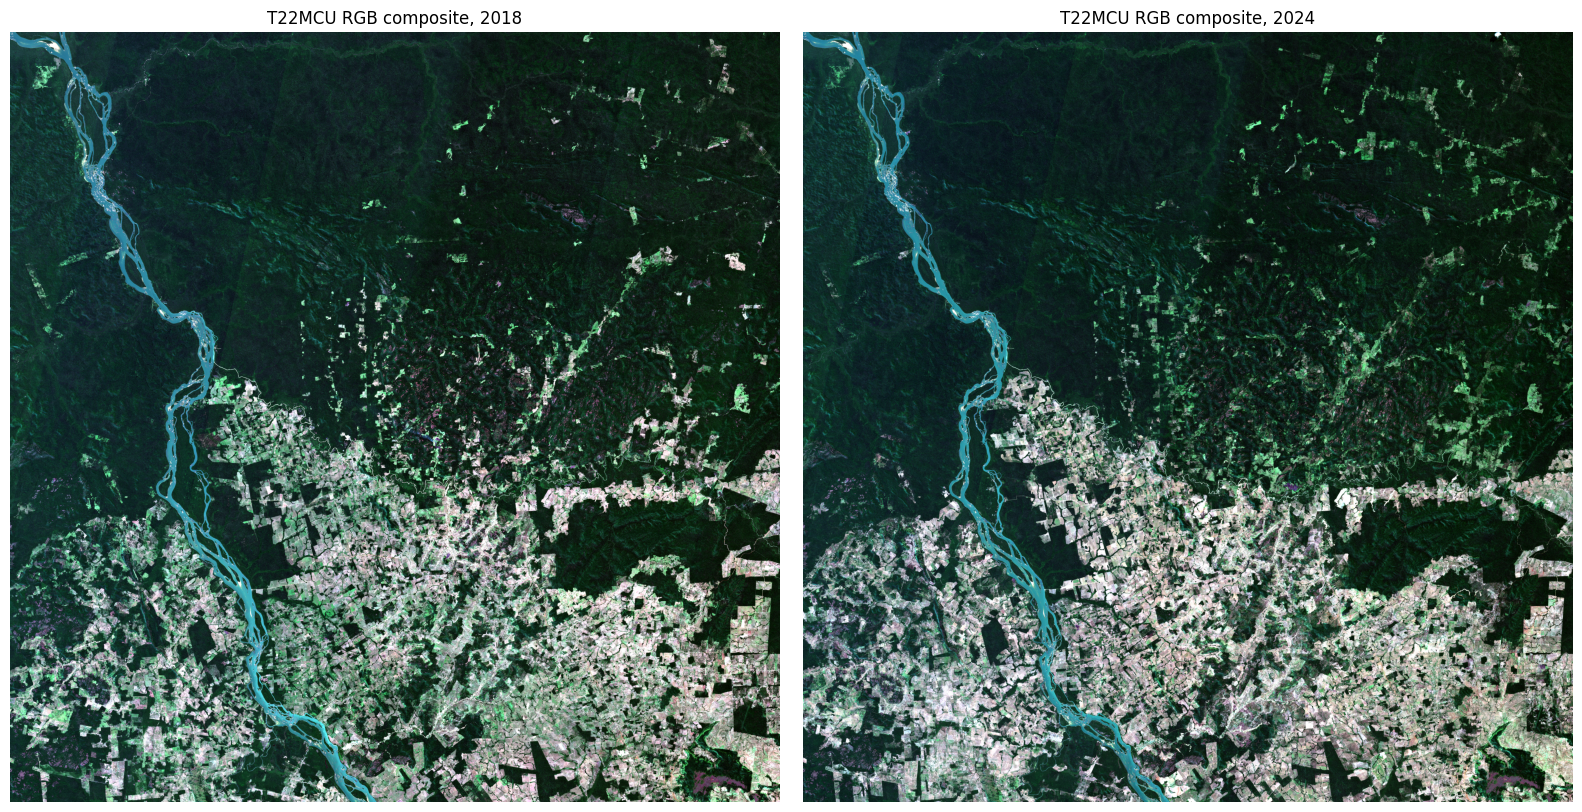

In [25]:
rgb_images = {}
"""
rgb_images = {
    2018: array(...), # shape: (H, W, 3),
    2018: array(...), # shape: (H, W, 3),
}
"""

for year in YEARS:
    rgb_images[year] = create_rgb_composite(band_files_by_year[year]) # band_files_by_year: {<year>: [<band_path>]}

figure, axes = plt.subplots(1, 2, figsize=(16, 8))

for axis, year in zip(axes, YEARS):
    axis.imshow(rgb_images[year])
    axis.set_title(f"T22MCU RGB composite, {year}")
    axis.axis("off")

plt.tight_layout()
plt.show()

##### Interpretation

* **Land cover:** The 2024 image shows more extensive bright, pale areas in the southern and central portions, suggesting increased built-up land, exposed soil, or cleared land compared with 2018.
* **Clearings and vegetation:** Forest in 2018 appears darker and more continuous. In 2024, the northern and eastern forest is more fragmented, with additional bright-green patches, narrow clearings, and irregular vegetation patterns.
* **Atmosphere:** Both images are largely cloud-free. The 2024 image is slightly brighter and greener overall, which may partly reflect seasonal or imaging differences rather than land-cover change alone.